***Step 6***

*Import data*

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import json

# --- Path setup --- must be before any 'from data import' ---
hour = int(os.environ['HOUR'])

if 'data' in sys.modules:
    del sys.modules['data']

sys.path.insert(0, os.environ['PYTHONPATH'])

from data import generators, generator_bid_prices, load_profile, load_distribution
from data import Prices_for_loads

# ── Variable names ─────────────────────────────────────────────────────
VARIABLES      = list(generators.keys())
LOAD_VARIABLES = list(load_distribution.keys())
conv_names     = [v for v in VARIABLES if v.startswith('G')]
wind_names     = [v for v in VARIABLES if v.startswith('W')]

# ── Raw data ───────────────────────────────────────────────────────────
gen_costs    = {g: generator_bid_prices[g][hour] for g in conv_names}  # marginal costs [EUR/MWh]
gen_max_caps = {g: generators[g]['Pmax_MW']      for g in conv_names}  # max capacities [MW]
hour_load    = load_profile[hour]                                       # total demand [MW]

# ── Wind capacity factors ──────────────────────────────────────────────
DATA_DIR = os.path.join(os.environ['PYTHONPATH'], 'data_from_Jakob')

W1_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone1.csv'))
W1_CF   = W1_data.iloc[1:25, 1:].mean(axis=1)

W2_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone2.csv'))
W2_CF   = W2_data.iloc[1:25, 1:].mean(axis=1)

W3_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone3.csv'))
W3_CF   = W3_data.iloc[1:25, 1:].mean(axis=1)

W4_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone4.csv'))
W4_CF   = W4_data.iloc[1:25, 1:].mean(axis=1)

W5_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone5.csv'))
W5_CF   = W5_data.iloc[1:25, 1:].mean(axis=1)

W6_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone6.csv'))
W6_CF   = W6_data.iloc[1:25, 1:].mean(axis=1)

Wind_DA = np.array([W1_CF[hour], W2_CF[hour], W3_CF[hour],
                    W4_CF[hour], W5_CF[hour], W6_CF[hour]]) * 200


**Reserve requirements**

In [2]:
R_up_req   = 0.15 * hour_load   # upward reserve requirement
R_down_req = 0.10 * hour_load   # downward reserve requirement

print(f"Upward reserve requirement:   {R_up_req:.2f} MW  (15% of {hour_load:.2f} MW)")
print(f"Downward reserve requirement: {R_down_req:.2f} MW  (10% of {hour_load:.2f} MW)")

Upward reserve requirement:   397.57 MW  (15% of 2650.50 MW)
Downward reserve requirement: 265.05 MW  (10% of 2650.50 MW)


**European style: reserve market first, then DA**

In [3]:
RESERVE_SUBSET = {'G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G9', 'G10', 'G11', 'G12'}

reserve_up_offers   = {}
reserve_down_offers = {}

for g in conv_names:
    if g not in RESERVE_SUBSET:
        continue

    c_i     = gen_costs[g]
    g_max_i = gen_max_caps[g]

    # R_g+ and R_g- are the max reserve bounds per generator (eq 35, 36)
    # Set to 30% of Pmax — consistent modelling choice to prevent
    # zero-cost generators from dominating the reserve market
    R_g_up   = 0.3 * g_max_i
    R_g_down = 0.3 * g_max_i

    # Upward reserve offer: 20% of marginal cost
    reserve_up_offers[g]   = (0.20 * c_i, R_g_up)

    # Downward reserve offer: 15% of marginal cost
    reserve_down_offers[g] = (0.15 * c_i, R_g_down)

print("Reserve upward offers (price = 20% of marginal cost, max = 30% of Pmax):")
for g, (p, mw) in reserve_up_offers.items():
    print(f"  {g}: {p:.2f} EUR/MWh   max {mw:.2f} MW  (C_g = {gen_costs[g]:.2f} EUR/MWh)")

print("\nReserve downward offers (price = 15% of marginal cost, max = 30% of Pmax):")
for g, (p, mw) in reserve_down_offers.items():
    print(f"  {g}: {p:.2f} EUR/MWh   max {mw:.2f} MW  (C_g = {gen_costs[g]:.2f} EUR/MWh)")

Reserve upward offers (price = 20% of marginal cost, max = 30% of Pmax):
  G1: 2.32 EUR/MWh   max 45.60 MW  (C_g = 11.59 EUR/MWh)
  G2: 2.32 EUR/MWh   max 45.60 MW  (C_g = 11.59 EUR/MWh)
  G3: 3.60 EUR/MWh   max 105.00 MW  (C_g = 18.01 EUR/MWh)
  G4: 3.64 EUR/MWh   max 177.30 MW  (C_g = 18.21 EUR/MWh)
  G5: 4.54 EUR/MWh   max 18.00 MW  (C_g = 22.72 EUR/MWh)
  G6: 1.83 EUR/MWh   max 46.50 MW  (C_g = 9.15 EUR/MWh)
  G7: 1.83 EUR/MWh   max 46.50 MW  (C_g = 9.15 EUR/MWh)
  G9: 0.95 EUR/MWh   max 120.00 MW  (C_g = 4.76 EUR/MWh)
  G10: 0.00 EUR/MWh   max 90.00 MW  (C_g = 0.00 EUR/MWh)
  G11: 1.83 EUR/MWh   max 93.00 MW  (C_g = 9.15 EUR/MWh)
  G12: 1.89 EUR/MWh   max 105.00 MW  (C_g = 9.47 EUR/MWh)

Reserve downward offers (price = 15% of marginal cost, max = 30% of Pmax):
  G1: 1.74 EUR/MWh   max 45.60 MW  (C_g = 11.59 EUR/MWh)
  G2: 1.74 EUR/MWh   max 45.60 MW  (C_g = 11.59 EUR/MWh)
  G3: 2.70 EUR/MWh   max 105.00 MW  (C_g = 18.01 EUR/MWh)
  G4: 2.73 EUR/MWh   max 177.30 MW  (C_g = 18.21 EU

***Solve Reserve European Model***

In [4]:
model_R = gp.Model("ReserveMarket_European")
model_R.Params.OutputFlag     = 0
model_R.Params.InfUnbdInfo    = 1
model_R.Params.DualReductions = 0

# Reserve capacity variables (eq 35, 36)
r_up   = {g: model_R.addVar(lb=0, ub=reserve_up_offers[g][1],   name=f'rup_{g}')
          for g in reserve_up_offers}
r_down = {g: model_R.addVar(lb=0, ub=reserve_down_offers[g][1], name=f'rdn_{g}')
          for g in reserve_down_offers}

# Must meet reserve requirements (eq 33, 34)
c_up   = model_R.addConstr(gp.quicksum(r_up[g]   for g in r_up)   >= R_up_req,   name="req_up")
c_down = model_R.addConstr(gp.quicksum(r_down[g] for g in r_down) >= R_down_req, name="req_down")

# Combined up + down reserve cannot exceed Pmax per generator (eq 37)
c_combined = {g: model_R.addConstr(
    r_up[g] + r_down[g] <= gen_max_caps[g],
    name=f"combined_{g}")
    for g in r_up}

# Minimise total reserve procurement cost (eq 32)
obj_R = (gp.quicksum(reserve_up_offers[g][0]  * r_up[g]   for g in r_up) +
         gp.quicksum(reserve_down_offers[g][0] * r_down[g] for g in r_down))

model_R.setObjective(obj_R, GRB.MINIMIZE)
model_R.optimize()

# Reserve clearing prices (duals)
lambda_R_up   = c_up.Pi
lambda_R_down = c_down.Pi

print(f"Reserve up   clearing price: {lambda_R_up:.2f} EUR/MWh")
print(f"Reserve down clearing price: {lambda_R_down:.2f} EUR/MWh")

print(f"\nCommitted reserve capacity:")
for g in r_up:
    up_val   = r_up[g].X
    down_val = r_down[g].X if g in r_down else 0.0
    if up_val > 1e-3 or down_val > 1e-3:
        print(f"  {g}: up={up_val:.2f} MW  |  down={down_val:.2f} MW")

# Committed reserve per generator
reserved_up   = {g: r_up[g].X   for g in r_up}
reserved_down = {g: r_down[g].X for g in r_down}

# --- Generator earnings (paid at clearing price) ---
print(f"\nGenerator earnings in reserve market:")
tso_total_payment = 0
for g in RESERVE_SUBSET:
    earn_up    = lambda_R_up   * reserved_up.get(g, 0)
    earn_down  = lambda_R_down * reserved_down.get(g, 0)
    total_earn = earn_up + earn_down
    tso_total_payment += total_earn
    if total_earn > 1e-3:
        print(f"  {g}: up={earn_up:.2f} EUR  |  down={earn_down:.2f} EUR  |  total={total_earn:.2f} EUR")

print(f"\nTSO total reserve procurement cost: {tso_total_payment:.2f} EUR")

Set parameter Username


Set parameter LicenseID to value 2658987


Academic license - for non-commercial use only - expires 2026-04-29


Reserve up   clearing price: 1.89 EUR/MWh
Reserve down clearing price: 1.37 EUR/MWh

Committed reserve capacity:
  G6: up=46.50 MW  |  down=46.50 MW
  G7: up=46.50 MW  |  down=8.55 MW
  G9: up=120.00 MW  |  down=120.00 MW
  G10: up=90.00 MW  |  down=90.00 MW
  G11: up=93.00 MW  |  down=0.00 MW
  G12: up=1.57 MW  |  down=0.00 MW

Generator earnings in reserve market:
  G7: up=88.07 EUR  |  down=11.73 EUR  |  total=99.81 EUR
  G11: up=176.14 EUR  |  down=0.00 EUR  |  total=176.14 EUR
  G9: up=227.28 EUR  |  down=164.70 EUR  |  total=391.98 EUR
  G10: up=170.46 EUR  |  down=123.53 EUR  |  total=293.99 EUR
  G12: up=2.98 EUR  |  down=0.00 EUR  |  total=2.98 EUR
  G6: up=88.07 EUR  |  down=63.82 EUR  |  total=151.89 EUR

TSO total reserve procurement cost: 1116.79 EUR


***Solve DA market (European sequential)***

In [5]:
# --- Load setup ---
Load_percentage  = [v['percent'] for v in load_distribution.values()]
DA_load          = hour_load
Load_DA          = [DA_load * (p / 100) for p in Load_percentage]

# --- Demand bid prices ---
Demand_price_DA      = np.array(sorted(Prices_for_loads[hour], reverse=True))
Load_coefficients_DA = {LOAD_VARIABLES[i]: Demand_price_DA[i] for i in range(len(LOAD_VARIABLES))}

# --- Generator capacity bounds (includes wind) ---
Generator_UB    = [v['Pmax_MW'] for k, v in generators.items() if k.startswith('G')]
Constraints_rhs = Generator_UB + Wind_DA.tolist()

# Extended gen_max_caps including wind (for headroom constraint)
gen_max_caps_all = {VARIABLES[i]: Constraints_rhs[i] for i in range(len(VARIABLES))}

# --- Load lambda_DA from Step 1 JSON for comparison ---
results_path = os.path.join(os.environ['PYTHONPATH'], 'Results', 'DA_results_step1.json')
with open(results_path, 'r') as f:
    DA_results_step1 = json.load(f)
lambda_DA = DA_results_step1['lambda_DA_step1']

# --- Model ---
model_DA_eu = gp.Model("DA_European_AfterReserve")
model_DA_eu.Params.OutputFlag     = 0
model_DA_eu.Params.DualReductions = 0

# Generation variables
p_da = {}
for v, rhs in zip(VARIABLES, Constraints_rhs):
    p_da[v] = model_DA_eu.addVar(lb=0, ub=rhs, name=f'p_{v}')

# Load variables
p_load = {l: model_DA_eu.addVar(lb=0, ub=Load_DA[i], name=f'load_{l}')
          for i, l in enumerate(LOAD_VARIABLES)}

# --- Headroom: p_da[g] <= P_g_max - reserved_up[g] ---
c_headroom = {}
for g in reserved_up:
    c_headroom[g] = model_DA_eu.addConstr(
        p_da[g] <= gen_max_caps_all[g] - reserved_up[g],
        name=f"headroom_{g}"
    )

# --- Footroom: p_da[g] >= reserved_down[g] ---
c_footroom = {}
for g in reserved_down:
    c_footroom[g] = model_DA_eu.addConstr(
        p_da[g] >= reserved_down[g],
        name=f"footroom_{g}"
    )

# --- Demand balance ---
c_balance = model_DA_eu.addConstr(
    gp.quicksum(p_load[l] for l in p_load) - gp.quicksum(p_da[v] for v in p_da) == 0,
    name="balance"
)

# --- Maximise social welfare ---
obj_DA_eu = (gp.quicksum(Load_coefficients_DA[l] * p_load[l] for l in p_load) -
             gp.quicksum(gen_costs.get(g, 0) * p_da[g] for g in p_da))
model_DA_eu.setObjective(obj_DA_eu, GRB.MAXIMIZE)
model_DA_eu.optimize()

lambda_DA_eu = c_balance.Pi

# --- Results ---
print(f"DA clearing price (after reserve): {lambda_DA_eu:.2f} EUR/MWh")
print(f"Original DA price (no reserve):    {lambda_DA:.2f} EUR/MWh")
print(f"Price impact of reserve:           {lambda_DA_eu - lambda_DA:+.2f} EUR/MWh")

# Producer surplus
print(f"\nProducer surplus per generator:")
total_prod_surplus = 0
for g in p_da:
    if p_da[g].X > 1e-3:
        surplus = (lambda_DA_eu - gen_costs.get(g, 0)) * p_da[g].X
        total_prod_surplus += surplus
        print(f"  {g}: {surplus:.2f} EUR  (dispatch={p_da[g].X:.2f} MW, cost={gen_costs.get(g,0):.2f} EUR/MWh)")

# Consumer surplus
print(f"\nConsumer surplus per load:")
total_cons_surplus = 0
for l in p_load:
    if p_load[l].X > 1e-3:
        surplus = (Load_coefficients_DA[l] - lambda_DA_eu) * p_load[l].X
        total_cons_surplus += surplus
        print(f"  {l}: {surplus:.2f} EUR  (consumption={p_load[l].X:.2f} MW, bid={Load_coefficients_DA[l]:.2f} EUR/MWh)")

# What each load pays
print(f"\nTotal payment per load:")
for l in p_load:
    if p_load[l].X > 1e-3:  
        payment = lambda_DA_eu * p_load[l].X
        print(f"  {l}: {payment:.2f} EUR")

# Totals
social_welfare_eu = model_DA_eu.ObjVal
print(f"\nTotal producer surplus: {total_prod_surplus:.2f} EUR")
print(f"Total consumer surplus: {total_cons_surplus:.2f} EUR")
print(f"Social welfare (DA):    {social_welfare_eu:.2f} EUR")

DA clearing price (after reserve): 11.59 EUR/MWh
Original DA price (no reserve):    9.47 EUR/MWh
Price impact of reserve:           +2.12 EUR/MWh

Producer surplus per generator:
  G1: 0.00 EUR  (dispatch=151.09 MW, cost=11.59 EUR/MWh)
  G6: 264.74 EUR  (dispatch=108.50 MW, cost=9.15 EUR/MWh)
  G7: 264.74 EUR  (dispatch=108.50 MW, cost=9.15 EUR/MWh)
  G8: 2540.00 EUR  (dispatch=400.00 MW, cost=5.24 EUR/MWh)
  G9: 1912.40 EUR  (dispatch=280.00 MW, cost=4.76 EUR/MWh)
  G10: 2433.90 EUR  (dispatch=210.00 MW, cost=0.00 EUR/MWh)
  G11: 529.48 EUR  (dispatch=217.00 MW, cost=9.15 EUR/MWh)
  G12: 738.66 EUR  (dispatch=348.43 MW, cost=9.47 EUR/MWh)
  W1: 1525.59 EUR  (dispatch=131.63 MW, cost=0.00 EUR/MWh)
  W2: 1660.66 EUR  (dispatch=143.28 MW, cost=0.00 EUR/MWh)
  W3: 1652.08 EUR  (dispatch=142.54 MW, cost=0.00 EUR/MWh)
  W4: 1445.01 EUR  (dispatch=124.68 MW, cost=0.00 EUR/MWh)
  W5: 1679.21 EUR  (dispatch=144.88 MW, cost=0.00 EUR/MWh)
  W6: 1622.25 EUR  (dispatch=139.97 MW, cost=0.00 EUR/MWh

In [6]:
print(f"\nFootroom constraints (reserved_down):")
for g in reserved_down:
    print(f"  {g}: reserved_down={reserved_down[g]:.2f} MW, dispatch={p_da[g].X:.2f} MW")

print(f"\nHeadroom constraints (reserved_up):")  
for g in reserved_up:
    print(f"  {g}: reserved_up={reserved_up[g]:.2f} MW, max_cap={gen_max_caps_all[g]:.2f} MW, headroom_left={gen_max_caps_all[g]-reserved_up[g]-p_da[g].X:.2f} MW")


Footroom constraints (reserved_down):
  G1: reserved_down=0.00 MW, dispatch=151.09 MW
  G2: reserved_down=0.00 MW, dispatch=0.00 MW
  G3: reserved_down=0.00 MW, dispatch=0.00 MW
  G4: reserved_down=0.00 MW, dispatch=0.00 MW
  G5: reserved_down=0.00 MW, dispatch=0.00 MW
  G6: reserved_down=46.50 MW, dispatch=108.50 MW
  G7: reserved_down=8.55 MW, dispatch=108.50 MW
  G9: reserved_down=120.00 MW, dispatch=280.00 MW
  G10: reserved_down=90.00 MW, dispatch=210.00 MW
  G11: reserved_down=0.00 MW, dispatch=217.00 MW
  G12: reserved_down=0.00 MW, dispatch=348.43 MW

Headroom constraints (reserved_up):
  G1: reserved_up=0.00 MW, max_cap=152.00 MW, headroom_left=0.91 MW
  G2: reserved_up=0.00 MW, max_cap=152.00 MW, headroom_left=152.00 MW
  G3: reserved_up=0.00 MW, max_cap=350.00 MW, headroom_left=350.00 MW
  G4: reserved_up=0.00 MW, max_cap=591.00 MW, headroom_left=591.00 MW
  G5: reserved_up=0.00 MW, max_cap=60.00 MW, headroom_left=60.00 MW
  G6: reserved_up=46.50 MW, max_cap=155.00 MW, head

**Importing DA results from step 1**

In [7]:
# --- Load Step 1 DA results from JSON ---
results_path = os.path.join(os.environ['PYTHONPATH'], 'Results', 'DA_results_step1.json')
with open(results_path, 'r') as f:
    DA_results_step1 = json.load(f)

lambda_DA                    = DA_results_step1['lambda_DA_step1']
total_cost_step1             = DA_results_step1['total_cost_step1']
social_welfare_step1         = DA_results_step1['social_welfare_step1']
production_surplus_step1     = DA_results_step1['production_surplus_step1']
consumer_surplus_step1       = DA_results_step1['consumer_surplus_step1']
generator_profits_step1      = DA_results_step1['generator_profits_step1']    # dict {generator: profit}
consumer_utilities_step1     = DA_results_step1['consumer_utilities_step1']   # dict {load: utility}
dispatch_step1 = DA_results_step1['dispatch_step1']  # add this line

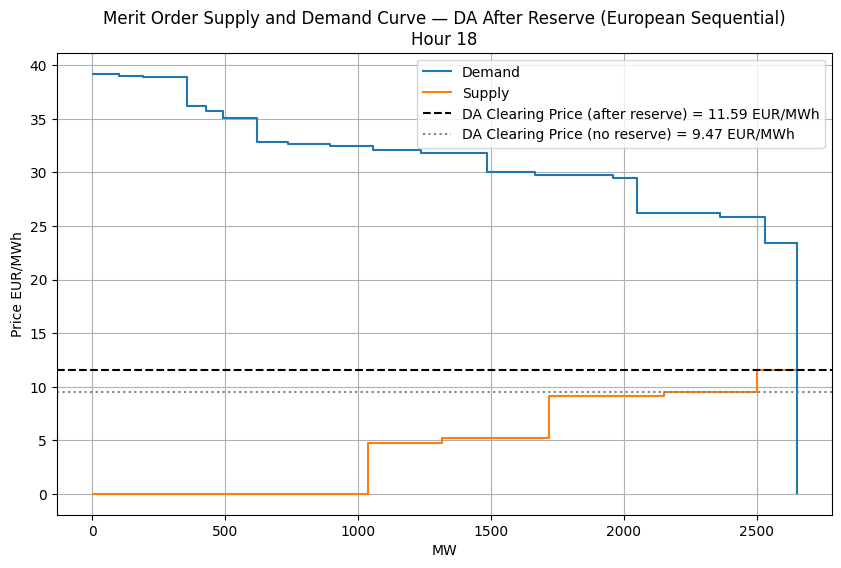

In [8]:
# --- Supply curve — use actual dispatch from model ---
supply_data_DA = [
    (gen_costs.get(g, 0), p_da[g].X)
    for g in VARIABLES
    if p_da[g].X > 1e-3
]
supply_data_sorted_DA = sorted(supply_data_DA, key=lambda x: x[0])
sorted_prices_DA      = [x[0] for x in supply_data_sorted_DA]
sorted_caps_DA        = [x[1] for x in supply_data_sorted_DA]
cumulative_supply_DA  = np.cumsum(sorted_caps_DA)

# --- Demand curve — use actual consumption from model ---
demand_data_DA = [
    (Load_coefficients_DA[l], p_load[l].X)
    for l in LOAD_VARIABLES
    if p_load[l].X > 1e-3
]
demand_data_sorted   = sorted(demand_data_DA, key=lambda x: x[0], reverse=True)
demand_sorted_prices = np.array([x[0] for x in demand_data_sorted])
demand_sorted_mw     = np.array([x[1] for x in demand_data_sorted])
cumulative_demand_DA = np.cumsum(demand_sorted_mw)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.step(cumulative_demand_DA, demand_sorted_prices, label='Demand', color='tab:blue')
plt.step(cumulative_supply_DA, sorted_prices_DA,     label='Supply', color='tab:orange')

plt.hlines(y=0,                       xmin=0, xmax=cumulative_supply_DA[0],  color='tab:orange')
plt.hlines(y=demand_sorted_prices[0], xmin=0, xmax=demand_sorted_mw[0],      color='tab:blue')
plt.vlines(x=cumulative_demand_DA[-1],ymin=0, ymax=demand_sorted_prices[-1], color='tab:blue')

plt.axhline(y=lambda_DA_eu, color='black', linestyle='--',
            label=f'DA Clearing Price (after reserve) = {lambda_DA_eu:.2f} EUR/MWh')
plt.axhline(y=lambda_DA, color='grey', linestyle=':',
            label=f'DA Clearing Price (no reserve) = {lambda_DA:.2f} EUR/MWh')

plt.xlabel('MW')
plt.ylabel('Price EUR/MWh')
plt.title(f'Merit Order Supply and Demand Curve — DA After Reserve (European Sequential)\nHour {hour}')
plt.legend()
plt.grid()
#plt.savefig(os.path.join(os.environ['PYTHONPATH'], 'Results', 'fig_step6_merit_order.png'),
#            dpi=150, bbox_inches='tight')
plt.show()

**DA without reserve vs DA with reserve**

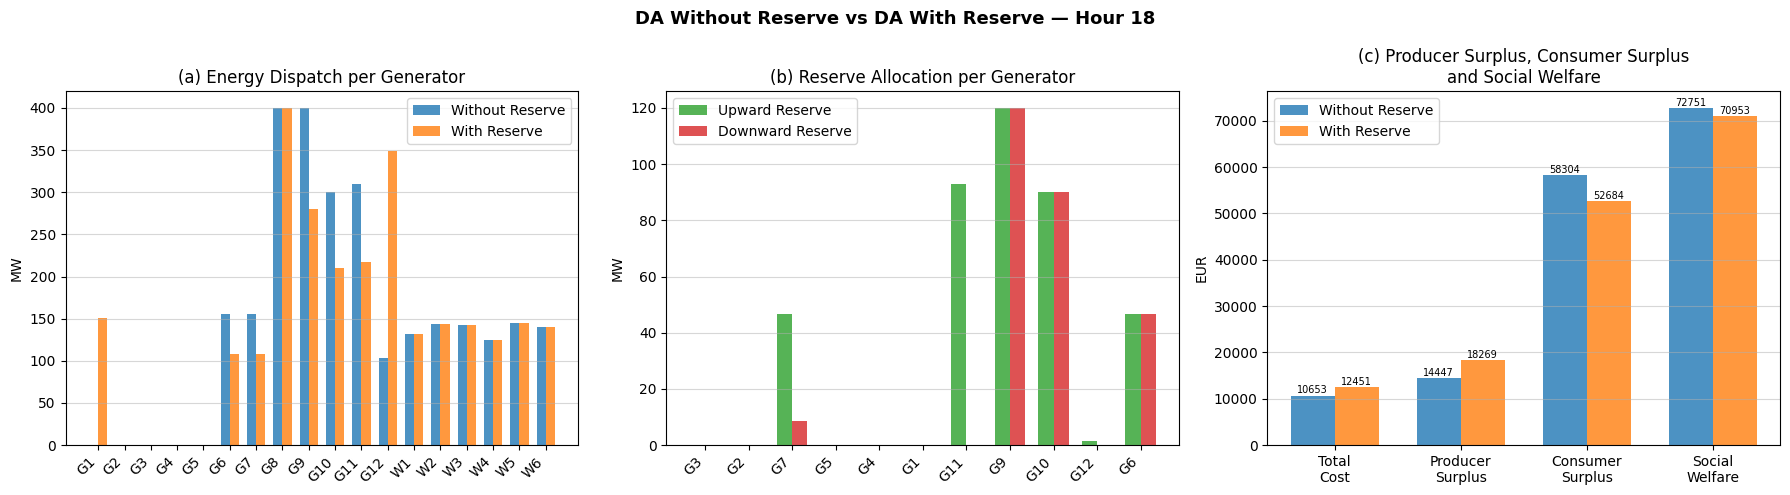


            Energy Clearing Price            
  Scenario                  Price (EUR/MWh)
  ----------------------------------------
  DA Without Reserve                   9.47
  DA With Reserve                     11.59
  Difference                          +2.12


In [9]:
# ── DA WITHOUT RESERVE vs DA WITH RESERVE ─────────────────────────────────────

RESULTS_DIR = os.path.join(os.environ['PYTHONPATH'], 'Results')
width       = 0.35

# --- Prepare data ---
all_gens      = list(p_da.keys())
no_res_disp   = [dispatch_step1.get(g, 0) for g in all_gens]
with_res_disp = [p_da[g].X for g in all_gens]

reserve_gens  = list(RESERVE_SUBSET)
ru_vals       = [reserved_up.get(g, 0)   for g in reserve_gens]
rd_vals       = [reserved_down.get(g, 0) for g in reserve_gens]

welfare_labels = ['Total\nCost', 'Producer\nSurplus', 'Consumer\nSurplus', 'Social\nWelfare']
no_res_vals    = [total_cost_step1, production_surplus_step1, consumer_surplus_step1, social_welfare_step1]
with_res_vals  = [sum(gen_costs.get(g, 0) * p_da[g].X for g in p_da),
                  total_prod_surplus, total_cons_surplus, social_welfare_eu]

# =============================================================================
# SAVED FIGURE — report quality, 3 subplots side by side
# =============================================================================
fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'DA Without Reserve vs DA With Reserve — Hour {hour}', fontsize=13, fontweight='bold')

# (a) Energy dispatch
x = np.arange(len(all_gens))
ax_a.bar(x - width/2, no_res_disp,   width, label='Without Reserve', color='tab:blue',   alpha=0.8)
ax_a.bar(x + width/2, with_res_disp, width, label='With Reserve',    color='tab:orange', alpha=0.8)
ax_a.set_xticks(x)
ax_a.set_xticklabels(all_gens, rotation=45, ha='right')
ax_a.set_ylabel('MW')
ax_a.set_title('(a) Energy Dispatch per Generator')
ax_a.legend()
ax_a.grid(axis='y', alpha=0.5)

# (b) Reserve allocation
x3 = np.arange(len(reserve_gens))
ax_b.bar(x3,         ru_vals, width, label='Upward Reserve',   color='tab:green', alpha=0.8)
ax_b.bar(x3 + width, rd_vals, width, label='Downward Reserve', color='tab:red',   alpha=0.8)
ax_b.set_xticks(x3 + width/2)
ax_b.set_xticklabels(reserve_gens, rotation=45, ha='right')
ax_b.set_ylabel('MW')
ax_b.set_title('(b) Reserve Allocation per Generator')
ax_b.legend()
ax_b.grid(axis='y', alpha=0.5)

# (c) Welfare comparison
x6 = np.arange(len(welfare_labels))
ax_c.bar(x6 - width/2, no_res_vals,   width, label='Without Reserve', color='tab:blue',   alpha=0.8)
ax_c.bar(x6 + width/2, with_res_vals, width, label='With Reserve',    color='tab:orange', alpha=0.8)
ax_c.set_xticks(x6)
ax_c.set_xticklabels(welfare_labels)
ax_c.set_ylabel('EUR')
ax_c.set_title('(c) Producer Surplus, Consumer Surplus\nand Social Welfare')
ax_c.legend()
ax_c.grid(axis='y', alpha=0.5)
for i, (nv, wv) in enumerate(zip(no_res_vals, with_res_vals)):
    ax_c.text(i - width/2, nv + 50, f'{nv:.0f}', ha='center', va='bottom', fontsize=7)
    ax_c.text(i + width/2, wv + 50, f'{wv:.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig11_DA_reserve_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Table: Energy Clearing Price ---
print(f"\n{'='*45}")
print(f"{'Energy Clearing Price':^45}")
print(f"{'='*45}")
print(f"  {'Scenario':<25} {'Price (EUR/MWh)':>15}")
print(f"  {'-'*40}")
print(f"  {'DA Without Reserve':<25} {lambda_DA:>15.2f}")
print(f"  {'DA With Reserve':<25} {lambda_DA_eu:>15.2f}")
print(f"  {'Difference':<25} {lambda_DA_eu - lambda_DA:>+15.2f}")
print(f"{'='*45}")

***US style: joint reserve + energy market***

In [10]:
# ── US-STYLE JOINT ENERGY + RESERVE MARKET ────────────────────────────────────
#
# The US joint market combines the DA and reserve markets into one optimisation.
# It includes all constraints from the European DA model, but r_up and r_down
# become decision variables instead of fixed parameters (eq 39, 40).
# The objective maximises social welfare minus reserve opportunity costs (eq 41).
# ──────────────────────────────────────────────────────────────────────────────

model_US = gp.Model("Joint_Reserve_Energy_US")
model_US.Params.OutputFlag     = 0
model_US.Params.DualReductions = 0

# --- Opportunity costs ---
C_ru = {g: 0.20 * gen_costs[g] for g in conv_names}
C_rd = {g: 0.15 * gen_costs[g] for g in conv_names}

# --- Decision variables ---
p_e  = {}   # energy dispatch [MW]
p_ru = {}   # upward reserve capacity [MW]
p_rd = {}   # downward reserve capacity [MW]

for g in conv_names:
    p_e[g]  = model_US.addVar(lb=0, ub=gen_max_caps[g], name=f'e_{g}')
    p_ru[g] = model_US.addVar(lb=0, name=f'ru_{g}')
    p_rd[g] = model_US.addVar(lb=0, name=f'rd_{g}')

    # HEADROOM: energy + upward reserve <= Pmax (eq 39 with r_up as variable)
    model_US.addConstr(p_e[g] + p_ru[g] <= gen_max_caps[g], name=f'cap_up_{g}')

    # FOOTROOM: downward reserve <= energy dispatched (eq 40 with r_down as variable)
    model_US.addConstr(p_rd[g] <= p_e[g],                   name=f'cap_dn_{g}')

    # MAX RESERVE BOUNDS: 30% of Pmax (consistent with European market)
    model_US.addConstr(p_ru[g] <= 0.3 * gen_max_caps[g],    name=f'max_ru_{g}')
    model_US.addConstr(p_rd[g] <= 0.3 * gen_max_caps[g],    name=f'max_rd_{g}')

    # Generators outside reserve subset cannot offer reserves
    if g not in RESERVE_SUBSET:
        model_US.addConstr(p_ru[g] == 0, name=f'no_ru_{g}')
        model_US.addConstr(p_rd[g] == 0, name=f'no_rd_{g}')

# --- Wind variables — energy only ---
p_w = {}
for wi, w in enumerate(wind_names):
    p_w[w] = model_US.addVar(lb=0, ub=Wind_DA[wi], name=f'e_{w}')

# --- Load variables (elastic demand, same as DA model) ---
p_load_US = {l: model_US.addVar(lb=0, ub=Load_DA[i], name=f'load_{l}')
             for i, l in enumerate(LOAD_VARIABLES)}

# --- Energy balance ---
# SIGN CONVENTION NOTE:
# The balance constraint is written as load - generation = 0 (same as DA model)
# to ensure consistent dual variable sign convention.
# Gurobi returns Pi with opposite sign for maximisation vs minimisation problems,
# and the sign also depends on which side of the equality the variables appear.
# By keeping load on the left and generation on the right (matching the DA model),
# c_balance_US.Pi gives the correct positive clearing price directly.
c_balance_US = model_US.addConstr(
    gp.quicksum(p_load_US[l] for l in p_load_US) -
    gp.quicksum(p_e[g] for g in p_e) -
    gp.quicksum(p_w[w] for w in p_w) == 0,
    name="energy_balance"
)

# --- Reserve requirements ---
# SIGN CONVENTION NOTE:
# For >= constraints in a maximisation problem, Gurobi returns negative duals.
# We negate them to recover the correct positive reserve clearing prices.
c_res_up_US = model_US.addConstr(
    gp.quicksum(p_ru[g] for g in p_ru) >= R_up_req,   name="res_up")
c_res_dn_US = model_US.addConstr(
    gp.quicksum(p_rd[g] for g in p_rd) >= R_down_req, name="res_down")

# --- Objective: maximise social welfare minus reserve opportunity costs (eq 41) ---
obj_US = (gp.quicksum(Load_coefficients_DA[l] * p_load_US[l] for l in p_load_US)
        - gp.quicksum(gen_costs[g] * p_e[g]  for g in p_e)
        - gp.quicksum(C_ru[g] * p_ru[g] + C_rd[g] * p_rd[g] for g in p_e))
model_US.setObjective(obj_US, GRB.MAXIMIZE)
model_US.optimize()

# --- Extract clearing prices from dual variables ---
# Energy price: direct from equality constraint dual (same sign convention as DA model)
# Reserve prices: negated because >= constraints return negative duals in maximisation
lambda_energy_US = c_balance_US.Pi
lambda_res_up_US = -c_res_up_US.Pi
lambda_res_dn_US = -c_res_dn_US.Pi

# --- Results ---
print(f"US-style joint market results:")
print(f"  Energy clearing price:  {lambda_energy_US:.2f} EUR/MWh")
print(f"  Upward reserve price:   {lambda_res_up_US:.2f} EUR/MWh")
print(f"  Downward reserve price: {lambda_res_dn_US:.2f} EUR/MWh")

print(f"\n  Dispatch:")
for g in p_e:
    if p_e[g].X > 1e-3 or p_ru[g].X > 1e-3 or p_rd[g].X > 1e-3:
        print(f"  {g}: energy={p_e[g].X:.2f} MW  r_up={p_ru[g].X:.2f} MW  r_dn={p_rd[g].X:.2f} MW")
for w in p_w:
    if p_w[w].X > 1e-3:
        print(f"  {w}: energy={p_w[w].X:.2f} MW")

US-style joint market results:
  Energy clearing price:  10.92 EUR/MWh
  Upward reserve price:   3.60 EUR/MWh
  Downward reserve price: 1.37 EUR/MWh

  Dispatch:
  G1: energy=0.00 MW  r_up=45.60 MW  r_dn=0.00 MW
  G2: energy=0.00 MW  r_up=45.60 MW  r_dn=0.00 MW
  G3: energy=0.00 MW  r_up=59.89 MW  r_dn=0.00 MW
  G6: energy=108.50 MW  r_up=46.50 MW  r_dn=46.50 MW
  G7: energy=108.50 MW  r_up=46.50 MW  r_dn=8.55 MW
  G8: energy=400.00 MW  r_up=0.00 MW  r_dn=0.00 MW
  G9: energy=400.00 MW  r_up=0.00 MW  r_dn=120.00 MW
  G10: energy=300.00 MW  r_up=0.00 MW  r_dn=90.00 MW
  G11: energy=261.51 MW  r_up=48.49 MW  r_dn=0.00 MW
  G12: energy=245.00 MW  r_up=105.00 MW  r_dn=0.00 MW
  W1: energy=131.63 MW
  W2: energy=143.28 MW
  W3: energy=142.54 MW
  W4: energy=124.68 MW
  W5: energy=144.88 MW
  W6: energy=139.97 MW


In [11]:
# --- Generator earnings in US joint market ---
print(f"\nGenerator earnings (US joint market):")
total_prod_surplus_US = 0

# Conventional generators
for g in p_e:
    earn_energy = (lambda_energy_US - gen_costs[g]) * p_e[g].X
    earn_ru     = lambda_res_up_US * p_ru[g].X
    earn_rd     = lambda_res_dn_US * p_rd[g].X
    total_earn  = earn_energy + earn_ru + earn_rd
    if p_e[g].X > 1e-3 or p_ru[g].X > 1e-3 or p_rd[g].X > 1e-3:
        total_prod_surplus_US += total_earn
        print(f"  {g}: energy={earn_energy:.2f} EUR  r_up={earn_ru:.2f} EUR  r_dn={earn_rd:.2f} EUR  total={total_earn:.2f} EUR")

# Wind farms — zero marginal cost, no reserve participation
for w in p_w:
    wind_surplus = lambda_energy_US * p_w[w].X  # cost = 0
    total_prod_surplus_US += wind_surplus
    if p_w[w].X > 1e-3:
        print(f"  {w}: energy={wind_surplus:.2f} EUR  (dispatch={p_w[w].X:.2f} MW)")

# --- Consumer surplus ---
total_cons_surplus_US = sum(
    (Load_coefficients_DA[l] - lambda_energy_US) * p_load_US[l].X
    for l in p_load_US
)

# --- Total demand payment ---
total_demand_payment_US = lambda_energy_US * sum(p_load_US[l].X for l in p_load_US)

# --- Total generation cost ---
total_gen_cost_US = sum(gen_costs[g] * p_e[g].X for g in p_e)

# --- Social welfare ---
# Computed as producer surplus + consumer surplus
# NOT using model_US.ObjVal because that includes reserve opportunity costs
# subtracted from the objective, which would distort the welfare comparison
social_welfare_US = total_prod_surplus_US + total_cons_surplus_US

# --- Results ---
print(f"\nTotal demand payment:   {total_demand_payment_US:.2f} EUR")
print(f"Total generation cost:  {total_gen_cost_US:.2f} EUR")
print(f"Total producer surplus: {total_prod_surplus_US:.2f} EUR")
print(f"Total consumer surplus: {total_cons_surplus_US:.2f} EUR")
print(f"Social welfare (US):    {social_welfare_US:.2f} EUR")

# --- Sanity checks ---
print(f"\nSanity checks:")
print(f"  Total load served:    {sum(p_load_US[l].X for l in p_load_US):.2f} MW  (should be {hour_load:.2f} MW)")
print(f"  Total generation:     {sum(p_e[g].X for g in p_e) + sum(p_w[w].X for w in p_w):.2f} MW")
print(f"  Upward reserve:       {sum(p_ru[g].X for g in p_ru):.2f} MW  (required {R_up_req:.2f} MW)")
print(f"  Downward reserve:     {sum(p_rd[g].X for g in p_rd):.2f} MW  (required {R_down_req:.2f} MW)")
print(f"  Prod + Cons surplus:  {total_prod_surplus_US + total_cons_surplus_US:.2f} EUR")
print(f"  model_US.ObjVal:      {model_US.ObjVal:.2f} EUR  (includes reserve costs subtracted)")

# --- Comparison with European sequential ---
print(f"\n{'='*60}")
print(f"Comparison: European Sequential vs US Joint")
print(f"{'='*60}")
print(f"  {'Metric':<30} {'EU Sequential':>15} {'US Joint':>15} {'Diff':>10}")
print(f"  {'-'*70}")
print(f"  {'Energy price (EUR/MWh)':<30} {lambda_DA_eu:>15.2f} {lambda_energy_US:>15.2f} {lambda_energy_US - lambda_DA_eu:>+10.2f}")
print(f"  {'Reserve up (EUR/MWh)':<30} {lambda_R_up:>15.2f} {lambda_res_up_US:>15.2f} {lambda_res_up_US - lambda_R_up:>+10.2f}")
print(f"  {'Reserve down (EUR/MWh)':<30} {lambda_R_down:>15.2f} {lambda_res_dn_US:>15.2f} {lambda_res_dn_US - lambda_R_down:>+10.2f}")
print(f"  {'Producer surplus (EUR)':<30} {total_prod_surplus:>15.2f} {total_prod_surplus_US:>15.2f} {total_prod_surplus_US - total_prod_surplus:>+10.2f}")
print(f"  {'Consumer surplus (EUR)':<30} {total_cons_surplus:>15.2f} {total_cons_surplus_US:>15.2f} {total_cons_surplus_US - total_cons_surplus:>+10.2f}")
print(f"  {'Social welfare (EUR)':<30} {social_welfare_eu:>15.2f} {social_welfare_US:>15.2f} {social_welfare_US - social_welfare_eu:>+10.2f}")
print(f"{'='*60}")


Generator earnings (US joint market):
  G1: energy=-0.00 EUR  r_up=164.25 EUR  r_dn=0.00 EUR  total=164.25 EUR
  G2: energy=-0.00 EUR  r_up=164.25 EUR  r_dn=0.00 EUR  total=164.25 EUR
  G3: energy=-0.00 EUR  r_up=215.71 EUR  r_dn=0.00 EUR  total=215.71 EUR
  G6: energy=192.26 EUR  r_up=167.49 EUR  r_dn=63.82 EUR  total=423.58 EUR
  G7: energy=192.26 EUR  r_up=167.49 EUR  r_dn=11.73 EUR  total=371.49 EUR
  G8: energy=2272.80 EUR  r_up=0.00 EUR  r_dn=0.00 EUR  total=2272.80 EUR
  G9: energy=2464.80 EUR  r_up=0.00 EUR  r_dn=164.70 EUR  total=2629.50 EUR
  G10: energy=3276.60 EUR  r_up=0.00 EUR  r_dn=123.53 EUR  total=3400.13 EUR
  G11: energy=463.40 EUR  r_up=174.66 EUR  r_dn=0.00 EUR  total=638.06 EUR
  G12: energy=355.74 EUR  r_up=378.21 EUR  r_dn=0.00 EUR  total=733.95 EUR
  W1: energy=1437.67 EUR  (dispatch=131.63 MW)
  W2: energy=1564.95 EUR  (dispatch=143.28 MW)
  W3: energy=1556.86 EUR  (dispatch=142.54 MW)
  W4: energy=1361.73 EUR  (dispatch=124.68 MW)
  W5: energy=1582.43 EUR  (

***European sequential vs US joint***

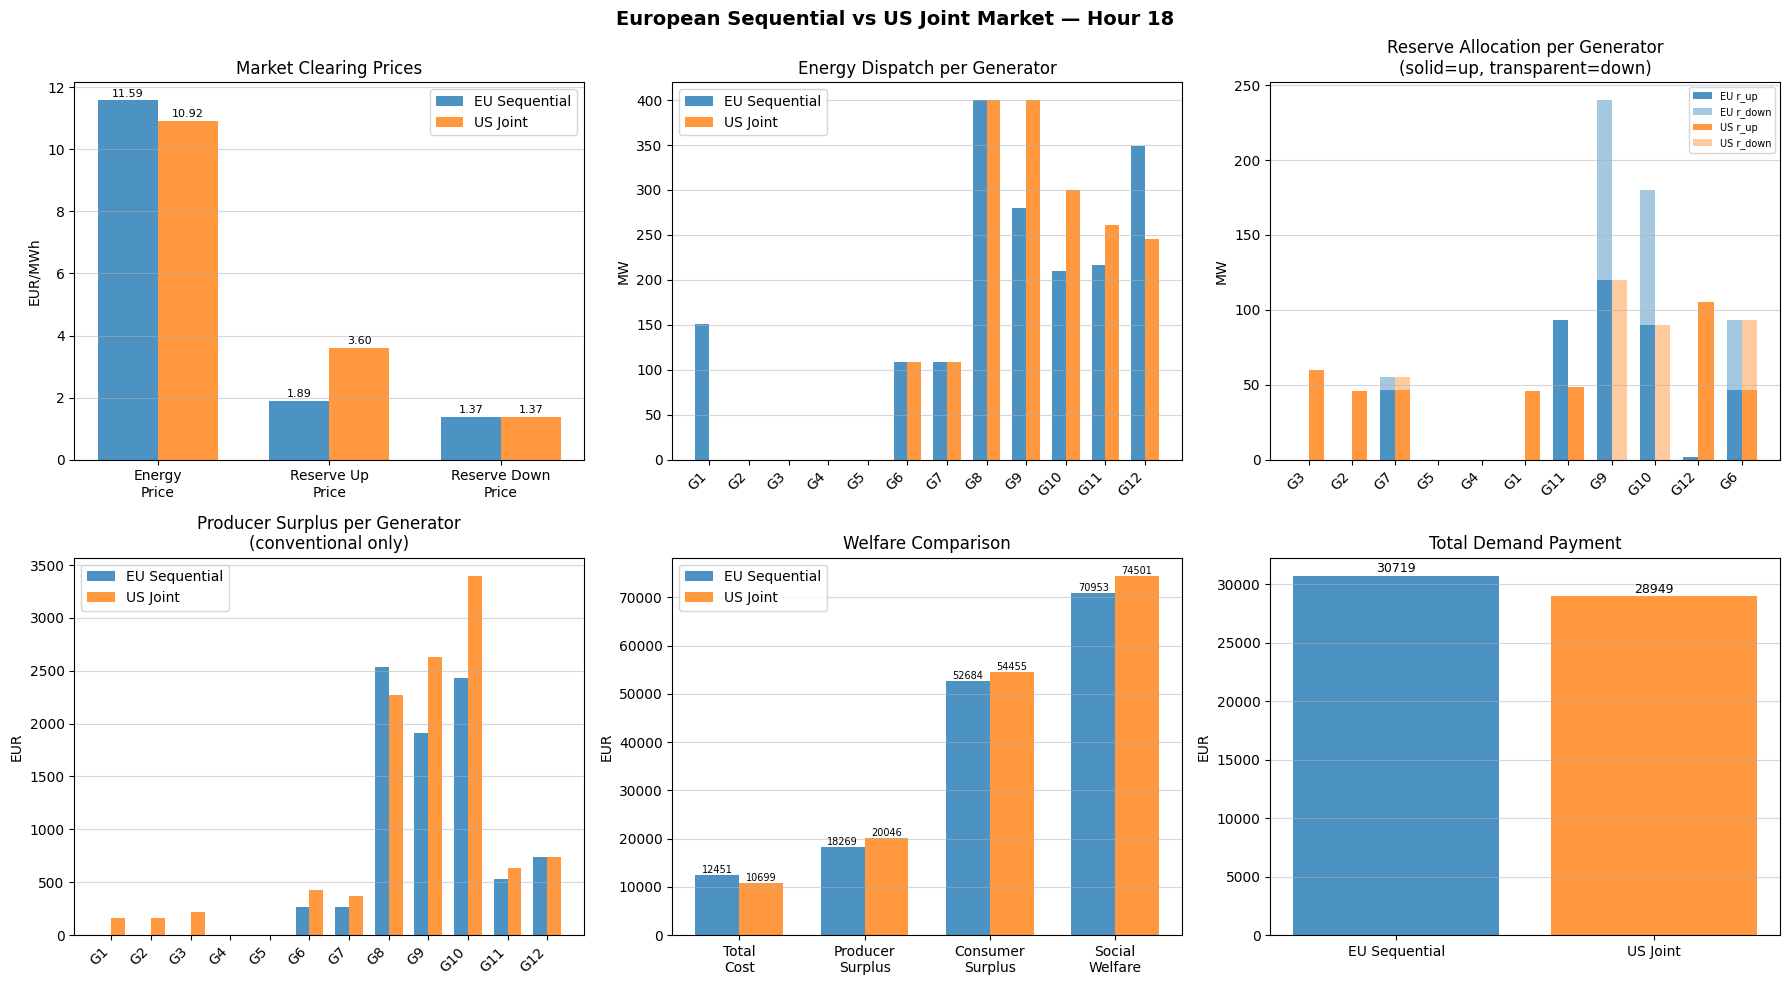

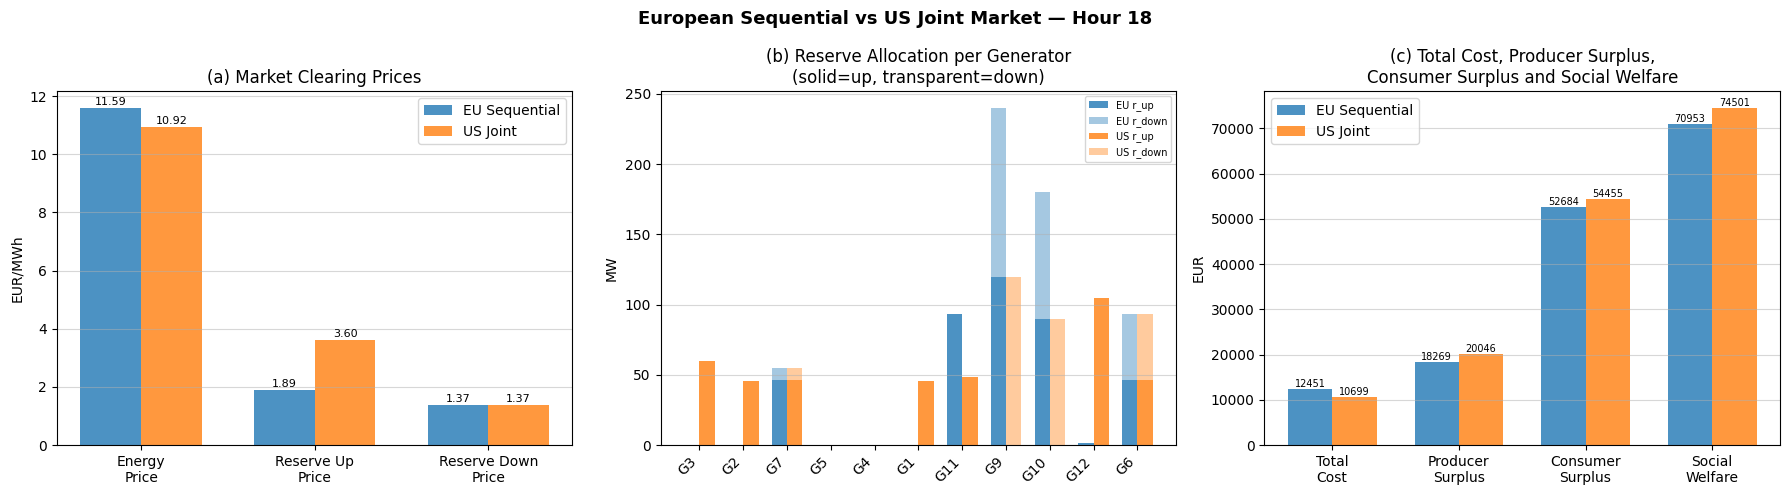

In [12]:
# ── EUROPEAN SEQUENTIAL vs US JOINT MARKET ────────────────────────────────────

RESULTS_DIR = os.path.join(os.environ['PYTHONPATH'], 'Results')
width       = 0.35

# --- Prepare data ---
gen_list     = list(p_e.keys())
reserve_gens = list(RESERVE_SUBSET)

eu_dispatch = [p_da[g].X if g in p_da else 0 for g in gen_list]
us_dispatch = [p_e[g].X                       for g in gen_list]

eu_ru = [reserved_up.get(g, 0)   for g in reserve_gens]
eu_rd = [reserved_down.get(g, 0) for g in reserve_gens]
us_ru = [p_ru[g].X               for g in reserve_gens]
us_rd = [p_rd[g].X               for g in reserve_gens]

# Producer surplus — must include wind farms for both EU and US
eu_prod = (sum((lambda_DA_eu     - gen_costs.get(g, 0)) * p_da[g].X for g in p_da
               if g in conv_names) +
           sum(lambda_DA_eu     * p_da[w].X for w in wind_names if w in p_da))

us_prod = (sum((lambda_energy_US - gen_costs.get(g, 0)) * p_e[g].X +
               lambda_res_up_US * p_ru[g].X +
               lambda_res_dn_US * p_rd[g].X for g in p_e) +
           sum(lambda_energy_US * p_w[w].X for w in p_w))

eu_cons = sum((Load_coefficients_DA[l] - lambda_DA_eu)     * p_load[l].X    for l in p_load)
us_cons = sum((Load_coefficients_DA[l] - lambda_energy_US) * p_load_US[l].X for l in p_load_US)

eu_prices = [lambda_DA_eu,     lambda_R_up,      lambda_R_down]
us_prices = [lambda_energy_US, lambda_res_up_US, lambda_res_dn_US]

welfare_labels_c = ['Total\nCost', 'Producer\nSurplus', 'Consumer\nSurplus', 'Social\nWelfare']
eu_welfare_c     = [sum(gen_costs.get(g, 0) * p_da[g].X for g in p_da),
                    eu_prod, eu_cons, eu_prod + eu_cons]
us_welfare_c     = [sum(gen_costs.get(g, 0) * p_e[g].X  for g in p_e),
                    us_prod, us_cons, us_prod + us_cons]

# =============================================================================
# DASHBOARD — shown in notebook only, not saved
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'European Sequential vs US Joint Market — Hour {hour}', fontsize=14, fontweight='bold')

# 1. Clearing prices
ax = axes[0, 0]
x = np.arange(3)
ax.bar(x - width/2, eu_prices, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax.bar(x + width/2, us_prices, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Energy\nPrice', 'Reserve Up\nPrice', 'Reserve Down\nPrice'])
ax.set_ylabel('EUR/MWh')
ax.set_title('Market Clearing Prices')
ax.legend()
ax.grid(axis='y', alpha=0.5)
for i, (eu, us) in enumerate(zip(eu_prices, us_prices)):
    ax.text(i - width/2, eu + 0.05, f'{eu:.2f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, us + 0.05, f'{us:.2f}', ha='center', va='bottom', fontsize=8)

# 2. Energy dispatch
ax = axes[0, 1]
x2 = np.arange(len(gen_list))
ax.bar(x2 - width/2, eu_dispatch, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax.bar(x2 + width/2, us_dispatch, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax.set_xticks(x2)
ax.set_xticklabels(gen_list, rotation=45, ha='right')
ax.set_ylabel('MW')
ax.set_title('Energy Dispatch per Generator')
ax.legend()
ax.grid(axis='y', alpha=0.5)

# 3. Reserve allocation
ax = axes[0, 2]
x3 = np.arange(len(reserve_gens))
ax.bar(x3 - width/2, eu_ru, width, label='EU r_up',   color='tab:blue',   alpha=0.8)
ax.bar(x3 - width/2, eu_rd, width, label='EU r_down', color='tab:blue',   alpha=0.4, bottom=eu_ru)
ax.bar(x3 + width/2, us_ru, width, label='US r_up',   color='tab:orange', alpha=0.8)
ax.bar(x3 + width/2, us_rd, width, label='US r_down', color='tab:orange', alpha=0.4, bottom=us_ru)
ax.set_xticks(x3)
ax.set_xticklabels(reserve_gens, rotation=45, ha='right')
ax.set_ylabel('MW')
ax.set_title('Reserve Allocation per Generator\n(solid=up, transparent=down)')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.5)

# 4. Producer surplus per generator (conv only — wind shown separately)
ax = axes[1, 0]
eu_surplus = [(lambda_DA_eu     - gen_costs.get(g, 0)) * p_da[g].X if g in p_da else 0 for g in gen_list]
us_surplus = [(lambda_energy_US - gen_costs.get(g, 0)) * p_e[g].X +
               lambda_res_up_US * p_ru[g].X +
               lambda_res_dn_US * p_rd[g].X for g in gen_list]
x4 = np.arange(len(gen_list))
ax.bar(x4 - width/2, eu_surplus, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax.bar(x4 + width/2, us_surplus, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax.set_xticks(x4)
ax.set_xticklabels(gen_list, rotation=45, ha='right')
ax.set_ylabel('EUR')
ax.set_title('Producer Surplus per Generator\n(conventional only)')
ax.legend()
ax.grid(axis='y', alpha=0.5)

# 5. Welfare comparison
ax = axes[1, 1]
x5 = np.arange(len(welfare_labels_c))
ax.bar(x5 - width/2, eu_welfare_c, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax.bar(x5 + width/2, us_welfare_c, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax.set_xticks(x5)
ax.set_xticklabels(welfare_labels_c)
ax.set_ylabel('EUR')
ax.set_title('Welfare Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.5)
for i, (eu, us) in enumerate(zip(eu_welfare_c, us_welfare_c)):
    ax.text(i - width/2, eu + 10, f'{eu:.0f}', ha='center', va='bottom', fontsize=7)
    ax.text(i + width/2, us + 10, f'{us:.0f}', ha='center', va='bottom', fontsize=7)

# 6. Total demand payment
ax = axes[1, 2]
payments = [lambda_DA_eu     * sum(p_load[l].X    for l in p_load),
            lambda_energy_US * sum(p_load_US[l].X for l in p_load_US)]
bars = ax.bar(['EU Sequential', 'US Joint'], payments, color=['tab:blue', 'tab:orange'], alpha=0.8)
ax.set_ylabel('EUR')
ax.set_title('Total Demand Payment')
ax.grid(axis='y', alpha=0.5)
for bar, val in zip(bars, payments):
    ax.text(bar.get_x() + bar.get_width()/2, val + 10, f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()  # dashboard shown in notebook only — NOT saved

# =============================================================================
# SAVED FIGURE — report quality, 3 subplots side by side
# =============================================================================
fig12, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(18, 5))
fig12.suptitle(f'European Sequential vs US Joint Market — Hour {hour}', fontsize=13, fontweight='bold')

# (a) Market clearing prices
x = np.arange(3)
ax_a.bar(x - width/2, eu_prices, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax_a.bar(x + width/2, us_prices, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax_a.set_xticks(x)
ax_a.set_xticklabels(['Energy\nPrice', 'Reserve Up\nPrice', 'Reserve Down\nPrice'])
ax_a.set_ylabel('EUR/MWh')
ax_a.set_title('(a) Market Clearing Prices')
ax_a.legend()
ax_a.grid(axis='y', alpha=0.5)
for i, (eu, us) in enumerate(zip(eu_prices, us_prices)):
    ax_a.text(i - width/2, eu + 0.05, f'{eu:.2f}', ha='center', va='bottom', fontsize=8)
    ax_a.text(i + width/2, us + 0.05, f'{us:.2f}', ha='center', va='bottom', fontsize=8)

# (b) Reserve allocation
x3 = np.arange(len(reserve_gens))
ax_b.bar(x3 - width/2, eu_ru, width, label='EU r_up',   color='tab:blue',   alpha=0.8)
ax_b.bar(x3 - width/2, eu_rd, width, label='EU r_down', color='tab:blue',   alpha=0.4, bottom=eu_ru)
ax_b.bar(x3 + width/2, us_ru, width, label='US r_up',   color='tab:orange', alpha=0.8)
ax_b.bar(x3 + width/2, us_rd, width, label='US r_down', color='tab:orange', alpha=0.4, bottom=us_ru)
ax_b.set_xticks(x3)
ax_b.set_xticklabels(reserve_gens, rotation=45, ha='right')
ax_b.set_ylabel('MW')
ax_b.set_title('(b) Reserve Allocation per Generator\n(solid=up, transparent=down)')
ax_b.legend(fontsize=7)
ax_b.grid(axis='y', alpha=0.5)

# (c) Total cost, producer surplus, consumer surplus and social welfare
x_c = np.arange(len(welfare_labels_c))
ax_c.bar(x_c - width/2, eu_welfare_c, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax_c.bar(x_c + width/2, us_welfare_c, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax_c.set_xticks(x_c)
ax_c.set_xticklabels(welfare_labels_c)
ax_c.set_ylabel('EUR')
ax_c.set_title('(c) Total Cost, Producer Surplus,\nConsumer Surplus and Social Welfare')
ax_c.legend()
ax_c.grid(axis='y', alpha=0.5)
for i, (eu, us) in enumerate(zip(eu_welfare_c, us_welfare_c)):
    ax_c.text(i - width/2, eu + 10, f'{eu:.0f}', ha='center', va='bottom', fontsize=7)
    ax_c.text(i + width/2, us + 10, f'{us:.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig12_EU_vs_US_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()